In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [3]:
np.random.seed(42)
n = 1000

data = pd.DataFrame({
    "km_per_day": np.random.randint(10, 200, n),
    "car_age_years": np.random.randint(0, 15, n),
    "service_per_year": np.random.randint(1, 6, n),
    "engine_type": np.random.choice(["Petrol", "Diesel", "Electric"], n),
    "road_condition": np.random.choice(["City", "Highway", "Mixed"], n)
})

data["remaining_life_years"] = (
    15
    - data["car_age_years"]
    - (data["km_per_day"] / 100) * 0.5
    + data["service_per_year"] * 0.3
    + np.random.normal(0, 1, n)
)

data["remaining_life_years"] = data["remaining_life_years"].clip(0, 15)

data.head()


,km_per_day,car_age_years,service_per_year,engine_type,road_condition,remaining_life_years
0,112,8,2,Diesel,Mixed,6.596956
1,189,1,5,Diesel,Mixed,14.075507
2,102,14,4,Diesel,City,1.986576
3,24,10,1,Electric,City,5.643185
4,116,7,3,Diesel,City,8.517292


In [4]:
X = data.drop("remaining_life_years", axis=1)
y = data["remaining_life_years"]


In [5]:
numerical_features = ["km_per_day", "car_age_years", "service_per_year"]
categorical_features = ["engine_type", "road_condition"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['km_per_day',
                                                   'car_age_years',
                                                   'service_per_year']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['engine_type',
                                                   'road_condition'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [8]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 0.9286791200102832
RMSE: 1.1779458051521194
R2 Score: 0.9326151956440226


In [9]:
new_car = pd.DataFrame({
    "km_per_day": [60],
    "car_age_years": [5],
    "service_per_year": [3],
    "engine_type": ["Petrol"],
    "road_condition": ["City"]
})

prediction = model.predict(new_car)
print(f"Estimated remaining car life: {prediction[0]:.2f} years")


Estimated remaining car life: 10.54 years


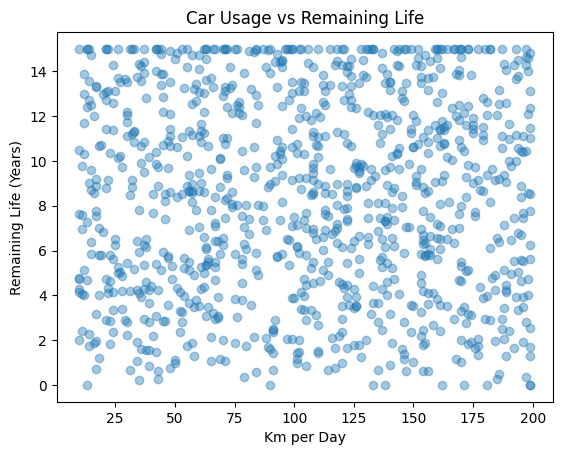

In [10]:
plt.scatter(data["km_per_day"], data["remaining_life_years"], alpha=0.4)
plt.xlabel("Km per Day")
plt.ylabel("Remaining Life (Years)")
plt.title("Car Usage vs Remaining Life")
plt.show()


In [11]:
import joblib


In [12]:
joblib.dump(model, "machine learning project.ipynb")


['machine learning project.ipynb']

In [13]:
!ls


'machine learning project.ipynb'   sample_data


In [15]:
from google.colab import files
files.download("machine learning project.ipynb")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()
